# Évaluation CL — Mahalanobis Distance — Dataset 2 Equipment Monitoring — by_location

| Champ | Valeur |
|-------|--------|
| **Modèle** | Mahalanobis Distance (détection d'anomalie, non-supervisé) |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Scénario** | by_location : Atlanta → Chicago → Houston → New York → San Francisco (5 tâches) |
| **Expérience** | exp_019 — voir experiments/exp_019_mahalanobis_monitoring_by_location/config_snapshot.yaml |
| **Sprint** | 7 — S7-11 |

> **Modèle non-supervisé** : Mahalanobis ne reçoit pas les labels à l'entraînement.  
> Score d'anomalie = distance de Mahalanobis à la distribution normale de la tâche courante.  
> RAM = 1 504 B — meilleure empreinte parmi les modèles non-supervisés (identique à by_equipment).  
> AF ≈ 0.002 — très faible oubli par design (μ et Σ⁻¹ recalculés à chaque tâche `refit`).  
> **Drift géographique** : 5 villes vs. 3 équipements. AA légèrement supérieur (0.9510 vs 0.9524).

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/monitoring_by_location/mahalanobis.ipynb \
    --output /tmp/mahalanobis_location_executed.ipynb --ExecutePreprocessor.timeout=600
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_location":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import (
    fit_pca2d,
    plot_feature_space_2d,
    plot_mahalanobis_ellipse,
)

# --- Chemins ---
EXP_DIR     = REPO_ROOT / "experiments/exp_019_mahalanobis_monitoring_by_location/results"
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/mahalanobis/monitoring/by_location"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH        = REPO_ROOT / "data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
NORMALIZER_PATH = REPO_ROOT / "configs/monitoring_normalizer.yaml"

# --- Constantes ---
TASK_NAMES    = ["Atlanta", "Chicago", "Houston", "New York", "San Francisco"]
MODEL_NAME    = "Mahalanobis"
DATA_AVAILABLE = CSV_PATH.exists()
RAM_LIMIT_BYTES = 64 * 1024

print(f"REPO_ROOT      : {REPO_ROOT}")
print(f"EXP_DIR        : {EXP_DIR}")
print(f"FIGURES_DIR    : {FIGURES_DIR}")
print(f"CSV disponible : {DATA_AVAILABLE}")
print(f"Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

if not DATA_AVAILABLE:
    display(Markdown(
        "> ⚠️ **CSV absent** — Sections 5, 6, 7, 8 en mode dégradé (données synthétiques). "
        "Placer `equipment_anomaly_data.csv` dans `data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/` pour le mode complet."
    ))

REPO_ROOT      : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR        : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_019_mahalanobis_monitoring_by_location/results
FIGURES_DIR    : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/mahalanobis/monitoring/by_location
CSV disponible : True
Date exécution : 2026-04-21 13:39


In [2]:
# Section 2 — Chargement des résultats exp_019
# Structure plate (aa/af/bwt directement à la racine du JSON)

metrics_path      = EXP_DIR / "metrics_mahalanobis_dataset2.json"
acc_matrix_path   = EXP_DIR / "acc_matrix_mahalanobis_dataset2.npy"
auroc_matrix_path = EXP_DIR / "auroc_matrix_mahalanobis_dataset2.npy"

metrics      = json.loads(metrics_path.read_text())
acc_matrix   = np.load(acc_matrix_path, allow_pickle=True)
auroc_matrix = np.load(auroc_matrix_path, allow_pickle=True) if auroc_matrix_path.exists() else None

# Reconstruction matrice numpy (None → NaN pour triangle supérieur)
acc_matrix_np = np.array(
    [[v if v is not None else np.nan for v in row] for row in metrics["acc_matrix"]],
    dtype=float,
)

ram_b  = metrics["ram_peak_bytes"]
lat    = metrics["inference_latency_ms"]
n_par  = metrics["n_params"]
within = metrics["memory"]["within_budget_64ko"]

print("=" * 55)
print(f"  Modèle         : {metrics['model']}")
print(f"  Scénario       : by_location (5 villes)")
print(f"  AA             = {metrics['aa']:.4f}")
print(f"  AF             = {metrics['af']:.4f}")
print(f"  BWT            = {metrics['bwt']:.4f}")
print(f"  FWT            = {metrics['fwt']:.4f}")
print(f"  AUROC moyen    = {metrics['auroc_avg']:.4f}")
print(f"  AUROC/tâche    = {[round(v, 4) for v in metrics['auroc_per_task']]}")
print(f"  RAM peak       = {ram_b} B ({ram_b/1024:.2f} Ko)")
print(f"  Latence        = {lat:.5f} ms")
print(f"  n_params       = {n_par} (d + d² pour d=4)")
print(f"  Budget 64 Ko   : {within}")
print("=" * 55)
print(f"\nMatrice acc ({acc_matrix_np.shape[0]}×{acc_matrix_np.shape[1]}) :")
print(acc_matrix_np)

  Modèle         : mahalanobis
  Scénario       : by_location (5 villes)
  AA             = 0.9510
  AF             = 0.0024
  BWT            = 0.0000
  FWT            = 0.0000
  AUROC moyen    = 0.9821
  AUROC/tâche    = [0.9751, 0.9931, 0.9879, 0.9716, 0.983]
  RAM peak       = 1504 B (1.47 Ko)
  Latence        = 0.00779 ms
  n_params       = 20 (d + d² pour d=4)
  Budget 64 Ko   : True

Matrice acc (5×5) :
[[0.96166134        nan        nan        nan        nan]
 [0.96485623 0.96141479        nan        nan        nan]
 [0.96166134 0.95498392 0.9483871         nan        nan]
 [0.95846645 0.95498392 0.9483871  0.95424837        nan]
 [0.96166134 0.95498392 0.95483871 0.95424837 0.92929293]]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/mahalanobis/monitoring/by_location/acc_matrix.png


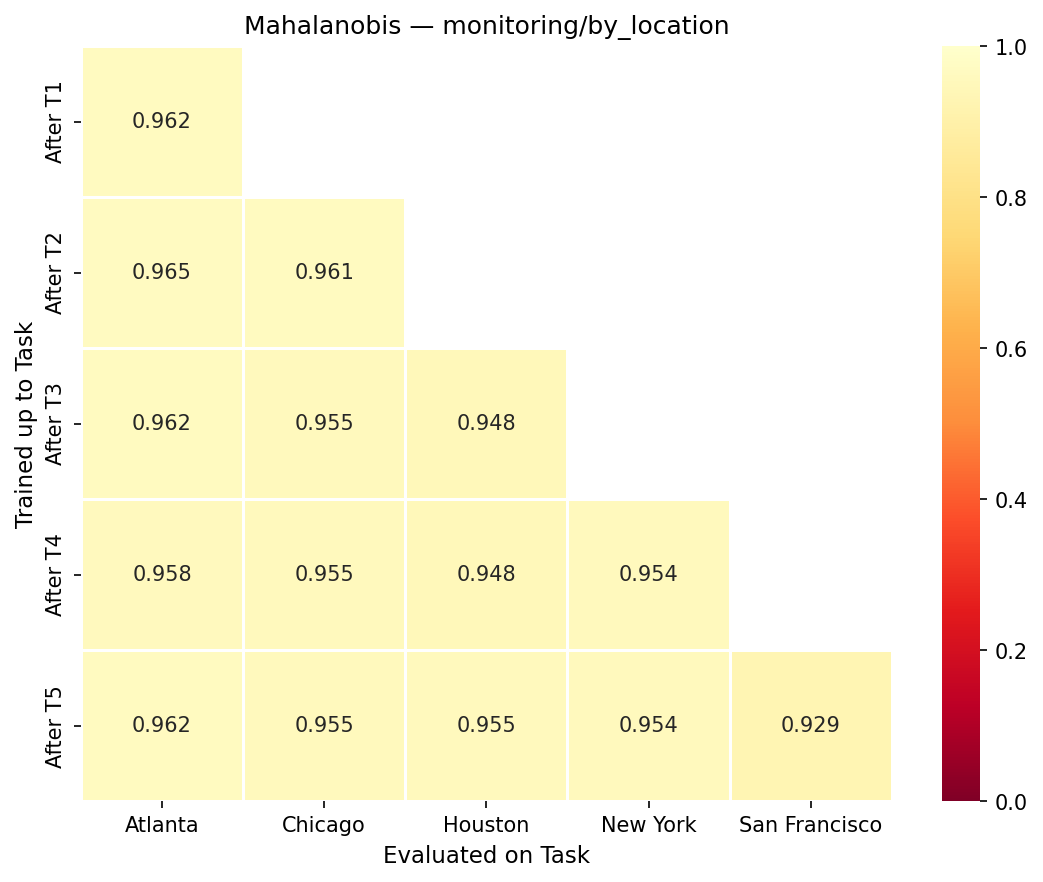

In [3]:
# Section 3 — Matrice d'accuracy (heatmap)
# Matrice 5×5 pour les 5 locations

fig = plot_accuracy_matrix(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — monitoring/by_location",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/mahalanobis/monitoring/by_location/forgetting_curve.png


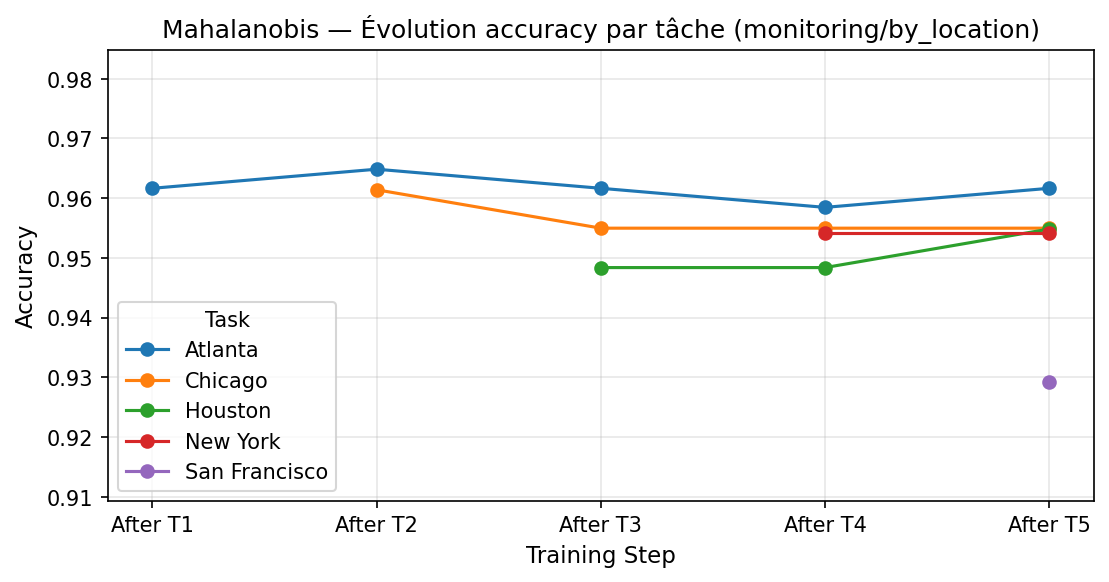

In [4]:
# Section 4 — Courbe d'oubli par tâche
# AF ≈ 0.0024 — quasi-nul (μ et Σ⁻¹ recalculés → distribution stable)
# 5 courbes pour les 5 locations

fig = plot_forgetting_curve(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — Évolution accuracy par tâche (monitoring/by_location)",
)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

In [5]:
# Section 5 — Rejeu du scénario CL (collecte preds_dict + scores_dict)
# Reproduit la config exp_019 : seed=42, anomaly_percentile=95, reg_covar=1e-6
# Sur 5 locations : Atlanta → Chicago → Houston → New York → San Francisco

preds_dict   = {}  # (i, j) → (y_true, y_pred)
scores_dict  = {}  # (i, j) → anomaly_scores
saved_mus    = {}  # task_id → mu_ (d,)
saved_sigmas = {}  # task_id → sigma_inv_ (d, d)
X_tests_raw  = []  # [N_val, 4] par tâche
y_tests_raw  = []  # [N_val] par tâche

if DATA_AVAILABLE:
    from src.data.monitoring_dataset import get_cl_dataloaders_by_location
    from src.models.unsupervised.mahalanobis_detector import MahalanobisDetector
    from src.utils.reproducibility import set_seed

    set_seed(42)

    tasks = get_cl_dataloaders_by_location(
        csv_path=CSV_PATH,
        normalizer_path=NORMALIZER_PATH,
        batch_size=32,
        seed=42,
        location_order=TASK_NAMES,
    )

    for t in tasks:
        X_v = np.concatenate([b[0].numpy() for b in t["val_loader"]])
        y_v = np.concatenate([b[1].numpy().flatten() for b in t["val_loader"]])
        X_tests_raw.append(X_v)
        y_tests_raw.append(y_v)

    model = MahalanobisDetector(config={"anomaly_percentile": 95, "reg_covar": 1e-6})

    for i, task in enumerate(tasks):
        domain = task.get("domain", TASK_NAMES[i])
        print(f"\n--- Tâche {i + 1}/{len(TASK_NAMES)} : {domain} ---")

        X_train = np.concatenate([b[0].numpy() for b in task["train_loader"]])
        model.fit_task(X_train, task_id=i)

        saved_mus[i]    = model.mu_.copy()
        saved_sigmas[i] = model.sigma_inv_.copy()

        for j in range(i + 1):
            scores = model.anomaly_score(X_tests_raw[j])
            y_pred = model.predict(X_tests_raw[j]).astype(float)
            preds_dict[(i, j)]  = (y_tests_raw[j], y_pred)
            scores_dict[(i, j)] = scores
            acc = (y_tests_raw[j] == y_pred.astype(int)).mean()
            print(f"  preds_dict[({i},{j})] → N={len(y_tests_raw[j])}, acc={acc:.4f}")

    print(f"\nScénario CL rejoué — {len(preds_dict)} évaluations collectées")

else:
    display(Markdown("> ⚠️ **Mode dégradé** — CSV absent. preds_dict synthétique depuis acc_matrix."))

    T = len(TASK_NAMES)
    N_SYNTH = 500
    rng = np.random.default_rng(42)
    y_synth = np.concatenate([np.zeros(N_SYNTH // 2), np.ones(N_SYNTH // 2)])

    for i in range(T):
        for j in range(i + 1):
            auroc_ij = metrics["auroc_per_task"][j] if j < len(metrics.get("auroc_per_task", [])) else 0.98
            noise = rng.normal(0, 0.08, N_SYNTH)
            scores_synth = np.where(y_synth == 1, 0.65 + noise, 0.25 + noise).clip(0, 1)
            threshold = np.percentile(scores_synth[:N_SYNTH // 2], 95)
            y_pred_synth = (scores_synth > threshold).astype(float)
            preds_dict[(i, j)]  = (y_synth.copy(), y_pred_synth)
            scores_dict[(i, j)] = scores_synth.astype(np.float32)

    print("preds_dict synthétique créé (mode dégradé — CSV absent)")

✅ Seed fixé à 42
✅ Seed fixé à 42

--- Tâche 1/5 : Atlanta ---
  [Mahalanobis] Tâche 0 — μ shape=(4,), Σ⁻¹ shape=(4, 4), RAM estimée=80 B
  [Mahalanobis] Seuil calculé sur Task 0 : 4.3666 (percentile 95)
  preds_dict[(0,0)] → N=313, acc=0.9617

--- Tâche 2/5 : Chicago ---
  [Mahalanobis] Tâche 1 — μ shape=(4,), Σ⁻¹ shape=(4, 4), RAM estimée=80 B
  preds_dict[(1,0)] → N=313, acc=0.9649
  preds_dict[(1,1)] → N=311, acc=0.9614

--- Tâche 3/5 : Houston ---
  [Mahalanobis] Tâche 2 — μ shape=(4,), Σ⁻¹ shape=(4, 4), RAM estimée=80 B
  preds_dict[(2,0)] → N=313, acc=0.9617
  preds_dict[(2,1)] → N=311, acc=0.9550
  preds_dict[(2,2)] → N=310, acc=0.9484

--- Tâche 4/5 : New York ---
  [Mahalanobis] Tâche 3 — μ shape=(4,), Σ⁻¹ shape=(4, 4), RAM estimée=80 B
  preds_dict[(3,0)] → N=313, acc=0.9585
  preds_dict[(3,1)] → N=311, acc=0.9550
  preds_dict[(3,2)] → N=310, acc=0.9484
  preds_dict[(3,3)] → N=306, acc=0.9542

--- Tâche 5/5 : San Francisco ---
  [Mahalanobis] Tâche 4 — μ shape=(4,), Σ⁻¹ shap

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/mahalanobis/monitoring/by_location/confusion_matrix_grid.png


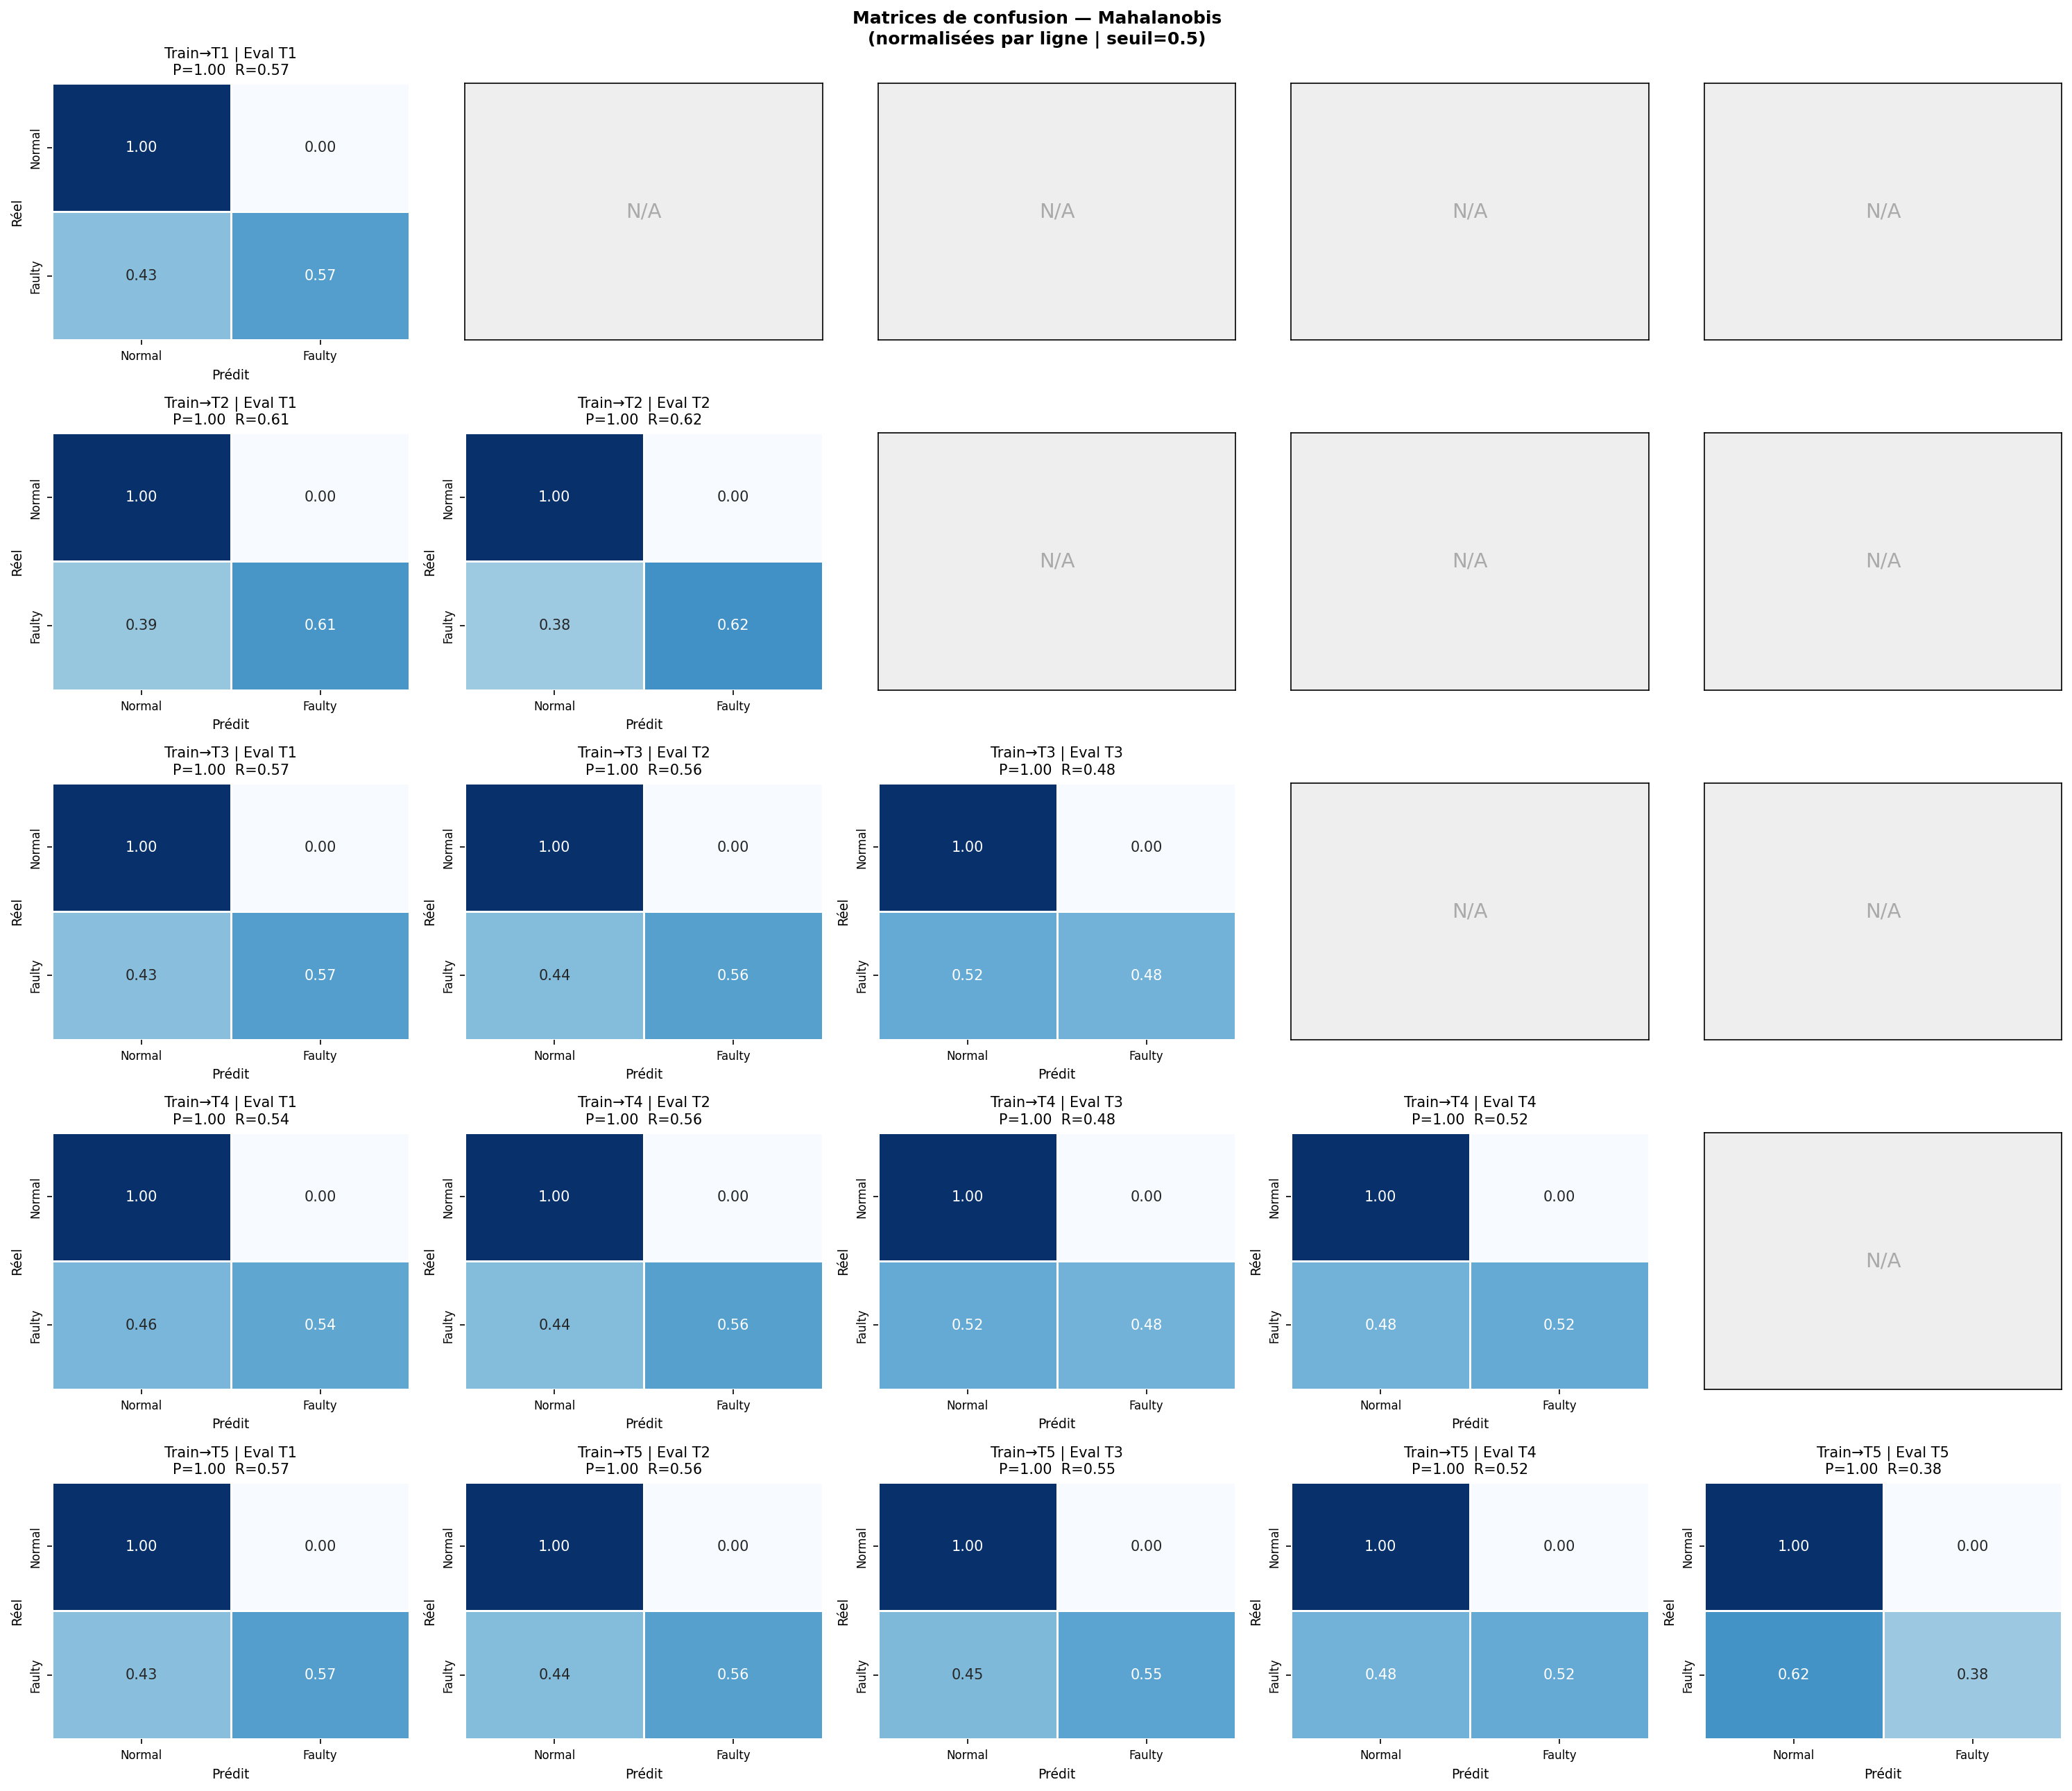

In [6]:
# Section 6 — Matrices de confusion par tâche (grille 5×5)

fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    threshold=0.5,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/mahalanobis/monitoring/by_location/auroc_curve.png


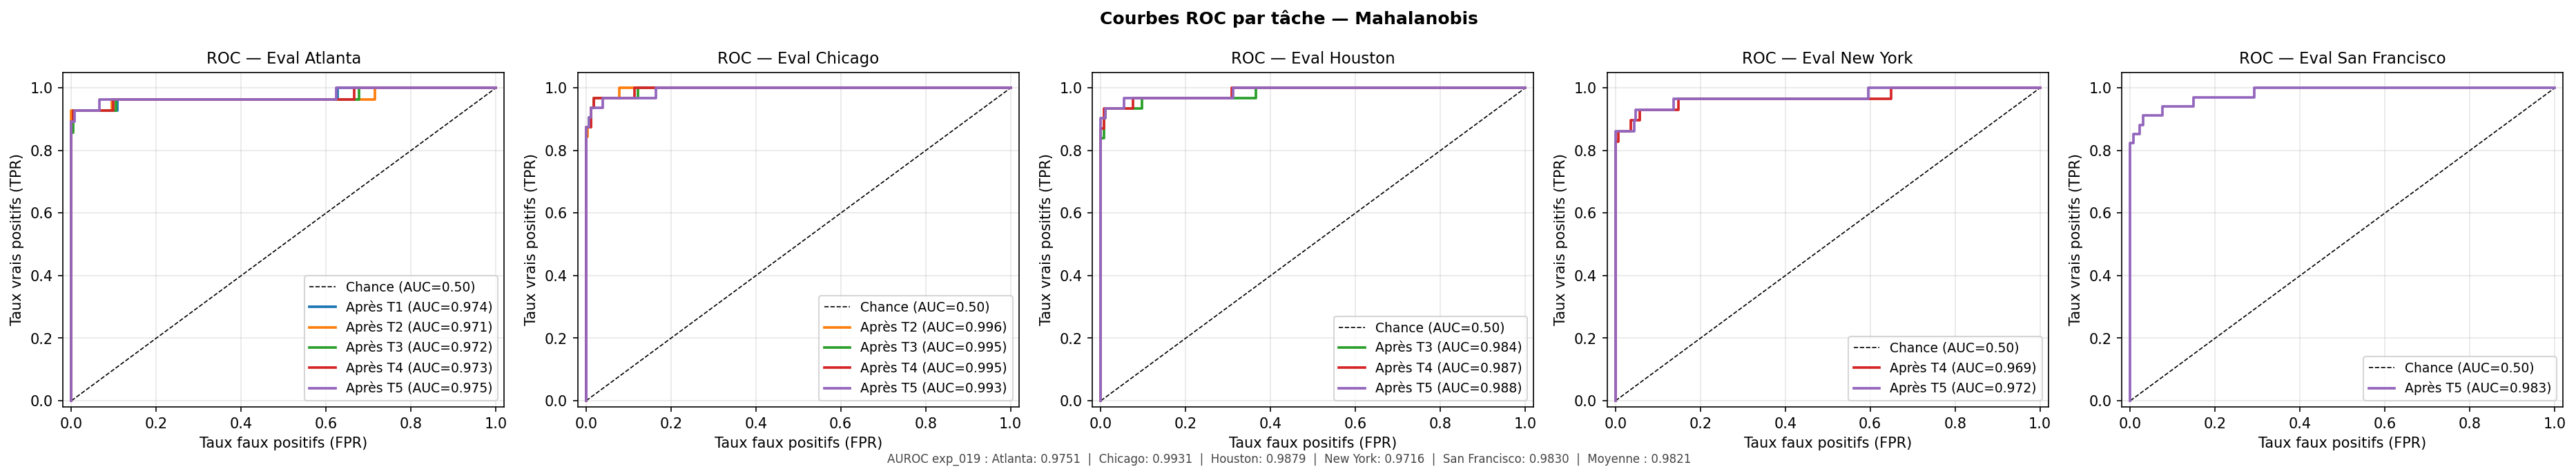

In [7]:
# Section 7 — Courbes AUROC par tâche
# La distance de Mahalanobis est un score continu → courbe ROC bien définie
# AUROC attendu ≈ 0.9821 (moyenne des 5 tâches)

auroc_per_task = metrics.get("auroc_per_task", [])
fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=scores_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)

if auroc_per_task:
    auroc_str = "  |  ".join(
        f"{TASK_NAMES[j]}: {auroc_per_task[j]:.4f}" for j in range(len(auroc_per_task))
    )
    fig.text(
        0.5, 0.01,
        f"AUROC exp_019 : {auroc_str}  |  Moyenne : {metrics['auroc_avg']:.4f}",
        ha="center", fontsize=8, color="#444444",
    )

save_figure(fig, FIGURES_DIR / "auroc_curve.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "auroc_curve.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/mahalanobis/monitoring/by_location/feature_space_pca.png


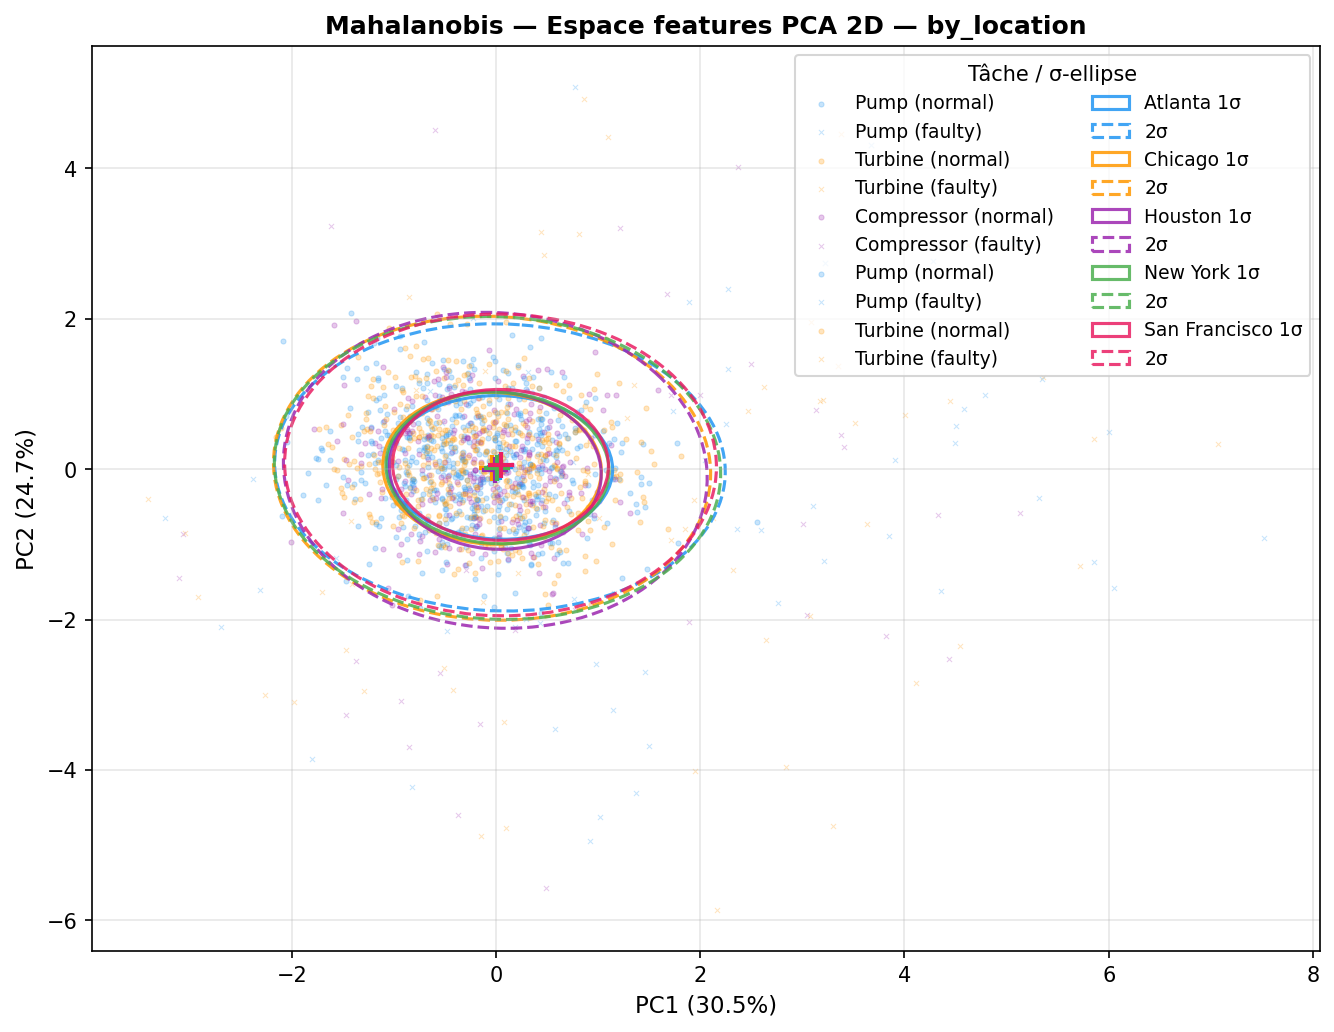

In [8]:
# Section 8 — Espace des features (PCA 2D + ellipses Mahalanobis)
# Visualise la distribution de chaque ville dans l'espace 2D PCA
# Ellipses 1σ / 2σ : contours de la distribution Mahalanobis par tâche (5 couleurs)

if DATA_AVAILABLE and len(X_tests_raw) == len(TASK_NAMES) and len(saved_mus) == len(TASK_NAMES):
    X_all      = np.concatenate(X_tests_raw, axis=0)
    y_all      = np.concatenate(y_tests_raw, axis=0)
    domain_ids = np.concatenate([
        np.full(len(X_tests_raw[k]), k) for k in range(len(TASK_NAMES))
    ])

    pca, X_proj = fit_pca2d(X_all)
    expl_var = pca.explained_variance_ratio_
    xlabel = f"PC1 ({expl_var[0]*100:.1f}%)"
    ylabel = f"PC2 ({expl_var[1]*100:.1f}%)"

    ELLIPSE_COLORS = ["#2196F3", "#FF9800", "#9C27B0", "#4CAF50", "#E91E63"]

    fig, ax = plt.subplots(figsize=(9, 7))

    plot_feature_space_2d(
        X_proj, y_all,
        title=f"{MODEL_NAME} — Espace features PCA 2D — by_location",
        ax=ax,
        domain_ids=domain_ids,
        alpha=0.25,
        s=6,
        xlabel=xlabel,
        ylabel=ylabel,
    )

    V = pca.components_  # (2, d)
    for task_id, (task_name, color) in enumerate(zip(TASK_NAMES, ELLIPSE_COLORS)):
        mu_d      = saved_mus[task_id]
        sigma_inv = saved_sigmas[task_id]
        cov_full  = np.linalg.pinv(sigma_inv)
        mu_proj   = V @ mu_d
        cov_proj  = V @ cov_full @ V.T
        plot_mahalanobis_ellipse(
            mu_proj, cov_proj, ax,
            sigmas=[1, 2],
            color=color,
            label=task_name,
        )

    ax.legend(fontsize=9, ncol=2, loc="upper right", title="Tâche / σ-ellipse")
    fig.tight_layout()
    save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
    plt.close(fig)
    display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

else:
    display(Markdown("> ⚠️ **Section 8 ignorée** — CSV absent ou scénario CL non rejoué."))
    print("[SKIP] feature_space_pca.png")

In [9]:
# Section 9 — Tableau récapitulatif

aa    = metrics["aa"]
af    = metrics["af"]
bwt   = metrics["bwt"]
auroc = metrics["auroc_avg"]
ram_ko = ram_b / 1024
forgetting_per_task = metrics.get("forgetting_per_task", [])

display(Markdown("### Résultats finaux — Mahalanobis — monitoring/by_location (exp_019)"))

recap_table = f"""
| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|---------|-------|-----------|----------|
| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:+.4f} | {auroc:.4f} | {ram_ko:.2f} Ko | {lat:.5f} ms | {n_par} scalaires |
"""
display(Markdown(recap_table))

print(f"Forgetting par tâche (Atlanta→Chicago→Houston→New York) : {[round(v, 4) for v in forgetting_per_task]}")
print()
print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)")
print("=" * 60)
print(f"  RAM = {ram_b} B = {ram_ko:.2f} Ko")
print(f"  Budget STM32N6 : 65 536 B (64 Ko)")
print(f"  Marge disponible : {65536 - ram_b} B ({(65536 - ram_b)/1024:.1f} Ko)")
print(f"  Mahalanobis occupe {ram_b / 65536 * 100:.2f}% du budget RAM")
print()
print(f"  FIXME(gap2) : 5 tâches × (d + d²) × 4B = 5 × 20 × 4 = 400 B pour stocker")
print(f"  tous les μ/Σ⁻¹ en mémoire (mode multi-task). RAM actuelle = tâche courante seulement.")
print()
print("  COMPARAISON by_equipment → by_location :")
print("    by_equipment : AA=0.9524, AF=0.001, AUROC=0.9718")
print(f"    by_location  : AA={aa:.4f}, AF={af:.4f}, AUROC={auroc:.4f}")
print("    → Mahalanobis est robuste au drift géographique.")
print()

print("=" * 60)
print("  Critères d'acceptation (S7-11)")
print("=" * 60)
for fig_name in ["acc_matrix.png", "forgetting_curve.png", "confusion_matrix_grid.png",
                 "auroc_curve.png", "feature_space_pca.png"]:
    status = "OK" if (FIGURES_DIR / fig_name).exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if abs(aa - 0.9510) < 0.01 else 'WARN'}] AA     = {aa:.4f}  (attendu ≈ 0.9510)")
print(f"  [{'OK' if abs(af - 0.0024) < 0.005 else 'WARN'}] AF     = {af:.4f}  (attendu ≈ 0.0024)")
print(f"  [{'OK' if abs(bwt) < 0.01 else 'WARN'}] BWT    = {bwt:+.4f} (attendu ≈ 0.0000)")
print(f"  [{'OK' if abs(auroc - 0.9821) < 0.005 else 'WARN'}] AUROC  = {auroc:.4f}  (attendu ≈ 0.9821)")
print(f"  [{'OK' if ram_b <= 65536 else 'FAIL (Gap2)'}] RAM    = {ram_ko:.2f} Ko (contrainte ≤ 64 Ko)")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence= {lat:.5f} ms (contrainte ≤ 100 ms)")

### Résultats finaux — Mahalanobis — monitoring/by_location (exp_019)


| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|---------|-------|-----------|----------|
| Mahalanobis | 0.9510 | 0.0024 | +0.0000 | 0.9821 | 1.47 Ko | 0.00779 ms | 20 scalaires |


Forgetting par tâche (Atlanta→Chicago→Houston→New York) : [0.0032, 0.0064, 0.0, 0.0]

  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)
  RAM = 1504 B = 1.47 Ko
  Budget STM32N6 : 65 536 B (64 Ko)
  Marge disponible : 64032 B (62.5 Ko)
  Mahalanobis occupe 2.29% du budget RAM

  FIXME(gap2) : 5 tâches × (d + d²) × 4B = 5 × 20 × 4 = 400 B pour stocker
  tous les μ/Σ⁻¹ en mémoire (mode multi-task). RAM actuelle = tâche courante seulement.

  COMPARAISON by_equipment → by_location :
    by_equipment : AA=0.9524, AF=0.001, AUROC=0.9718
    by_location  : AA=0.9510, AF=0.0024, AUROC=0.9821
    → Mahalanobis est robuste au drift géographique.

  Critères d'acceptation (S7-11)
  [OK] acc_matrix.png
  [OK] forgetting_curve.png
  [OK] confusion_matrix_grid.png
  [OK] auroc_curve.png
  [OK] feature_space_pca.png

  [OK] AA     = 0.9510  (attendu ≈ 0.9510)
  [OK] AF     = 0.0024  (attendu ≈ 0.0024)
  [OK] BWT    = +0.0000 (attendu ≈ 0.0000)
  [OK] AUROC  = 0.9821  (attendu ≈ 0.9821)
  [O